In [1]:
# Imports and paths
from pathlib import Path
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from skimage import io, filters, morphology, exposure, color
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from time import perf_counter
from torch.cuda.amp import autocast


/home/sec312/tsgh/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 12
# Paths (update as needed)
REP_DIR = Path('process/train-512-lv1')  # 30 tiles with four categories inside subfolders
FULL_DATA_DIR = Path('process/tile/level-train-batch4')     # root with large 2k tiles
MASK_CACHE_DIR = Path('process/output')         # where generated full-size masks will be stored
MASK_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CROP_SIZE = 512
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Step 0 – 載入並視覺化 30 個代表性圖塊

strong 10 files found
weak 5 files found
negative 10 files found
blank 5 files found


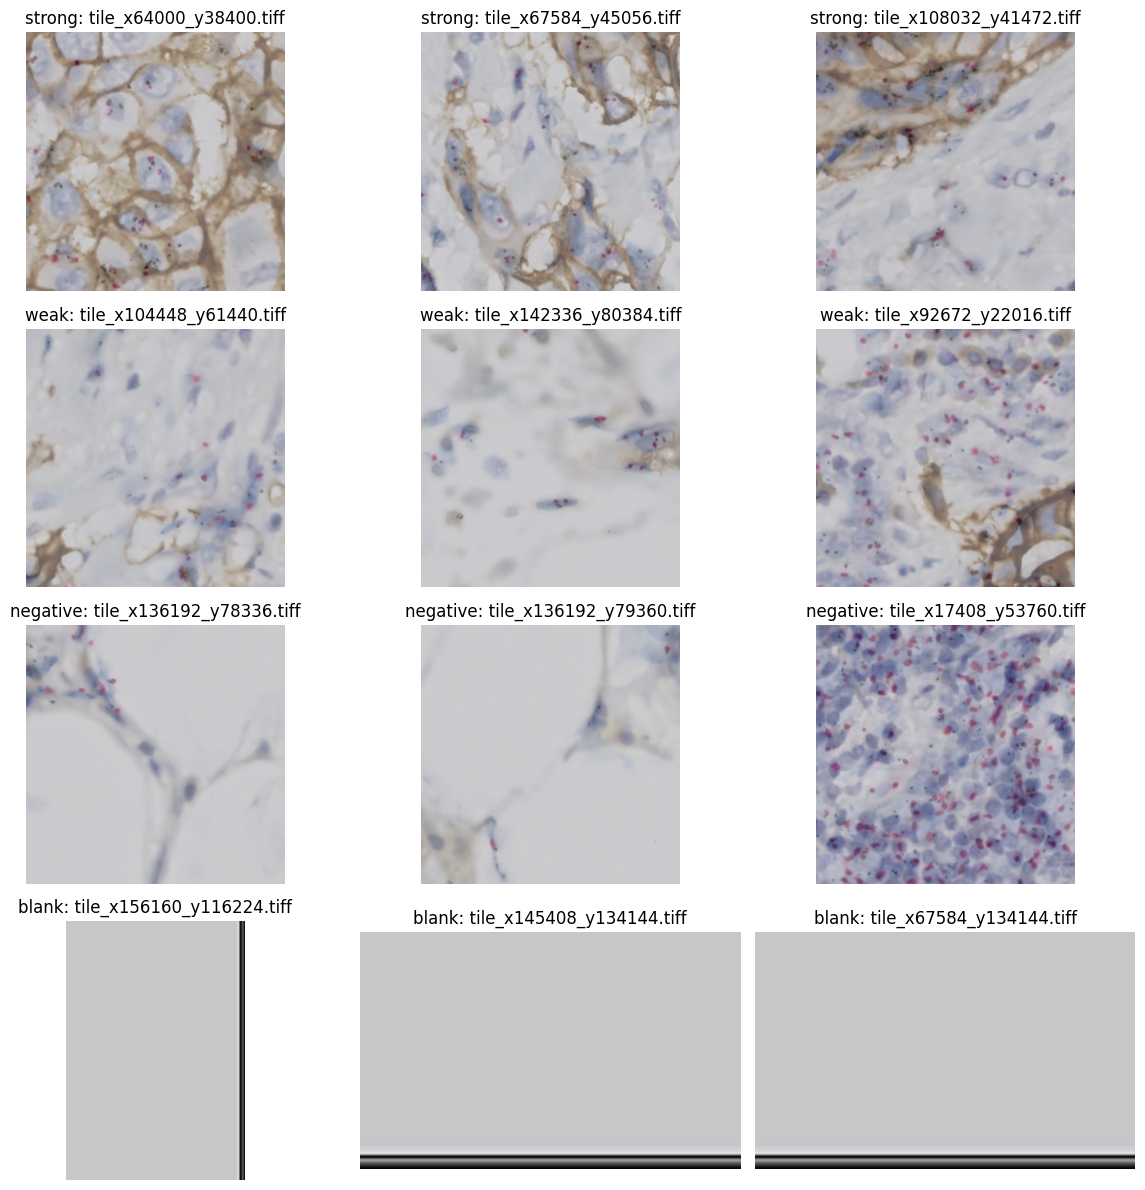

In [3]:
# Collect representative tiles by category and show a small grid
CATEGORY_ALIASES = {
    'strong': ['strong', 'strong_positive', '3plus', '3+'],
    'weak': ['weak', 'weak_brown', '1plus', '2plus'],
    'negative': ['negative', 'neg'],
    'blank': ['blank', 'empty', 'white']
}

def collect_category_files(base_dir: Path, aliases: dict, limit: int | None = None):
    paths_by_cat = {}
    for cat, names in aliases.items():
        candidates = []
        for name in names:
            for ext in ('*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff'):
                candidates.extend(sorted((base_dir / name).glob(ext)))
        # unique while preserving order
        seen = set()
        unique_paths = []
        for p in candidates:
            if p not in seen:
                unique_paths.append(p)
                seen.add(p)
        if limit is not None:
            unique_paths = unique_paths[:limit]
        paths_by_cat[cat] = unique_paths
    return paths_by_cat

rep_paths_by_cat = collect_category_files(REP_DIR, CATEGORY_ALIASES, limit=10)
for cat, paths in rep_paths_by_cat.items():
    print(cat, len(paths), 'files found')

def show_representative_grid(paths_by_cat: dict, samples_per_cat: int = 3):
    fig, axes = plt.subplots(len(paths_by_cat), samples_per_cat, figsize=(4 * samples_per_cat, 3 * len(paths_by_cat)))
    if len(paths_by_cat) == 1:
        axes = np.expand_dims(axes, 0)
    for row_idx, (cat, paths) in enumerate(paths_by_cat.items()):
        selected = random.sample(paths, k=min(samples_per_cat, len(paths))) if paths else []
        for col_idx in range(samples_per_cat):
            ax = axes[row_idx, col_idx] if paths_by_cat else axes[col_idx]
            if col_idx < len(selected):
                img = np.array(Image.open(selected[col_idx]).convert('RGB'))
                ax.imshow(img)
                ax.set_title(f"{cat}: {selected[col_idx].name}")
            else:
                ax.axis('off')
            ax.axis('off')
    plt.tight_layout()
    plt.show()

show_representative_grid(rep_paths_by_cat, samples_per_cat=3)

### Step 1 – Calibrate pseudo-mask generator
運行預覽單元格，並在繼續操作之前，透過視覺確認它是否抑制了負面/空白圖塊並保留了弱/強環。

In [4]:
def _read_rgb_uint8(path: Path) -> np.ndarray:
    img = io.imread(path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.shape[2] == 4:
        img = img[..., :3]
    if img.dtype != np.uint8:
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    return img 

In [5]:
def generate_pseudo_mask(image_path: Path) -> np.ndarray:
    img = _read_rgb_uint8(image_path)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    
    # === 策略改變 ===
    # 1. 先抓出所有 "暖色系" (包含紅色、橘色、棕色)
    # Hue: 0-30 (紅~橘黃) 以及 160-180 (紫紅~紅)
    # Saturation: > 20 (排除背景白)
    # Value: < 235 (排除純白背景)
    
    # Mask 1: Hue 0-30 (涵蓋大部分棕色跟紅色)
    lower_warm1 = np.array([0, 20, 20], dtype=np.uint8)
    upper_warm1 = np.array([30, 255, 235], dtype=np.uint8)
    mask_warm1 = cv2.inRange(hsv, lower_warm1, upper_warm1)
    
    # Mask 2: Hue 160-180 (涵蓋偏紫的紅色)
    lower_warm2 = np.array([160, 20, 20], dtype=np.uint8)
    upper_warm2 = np.array([180, 255, 235], dtype=np.uint8)
    mask_warm2 = cv2.inRange(hsv, lower_warm2, upper_warm2)
    
    # 合併暖色遮罩 (這時候包含了 棕色環 + 紅點)
    mask_warm = cv2.bitwise_or(mask_warm1, mask_warm2)
    
    mask_darker = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 160]))
    
    # 最終 Mask = 暖色系 AND 足夠暗
    final_mask = cv2.bitwise_and(mask_warm, mask_darker)
    
    # 3. 形態學修補
    kernel_open = np.ones((3, 3), np.uint8)
    kernel_close = np.ones((5, 5), np.uint8)
    
    # 先 Open 去除噪點
    final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_OPEN, kernel_open)
    # 再 Close 把環連起來
    final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel_close)
    
    return final_mask

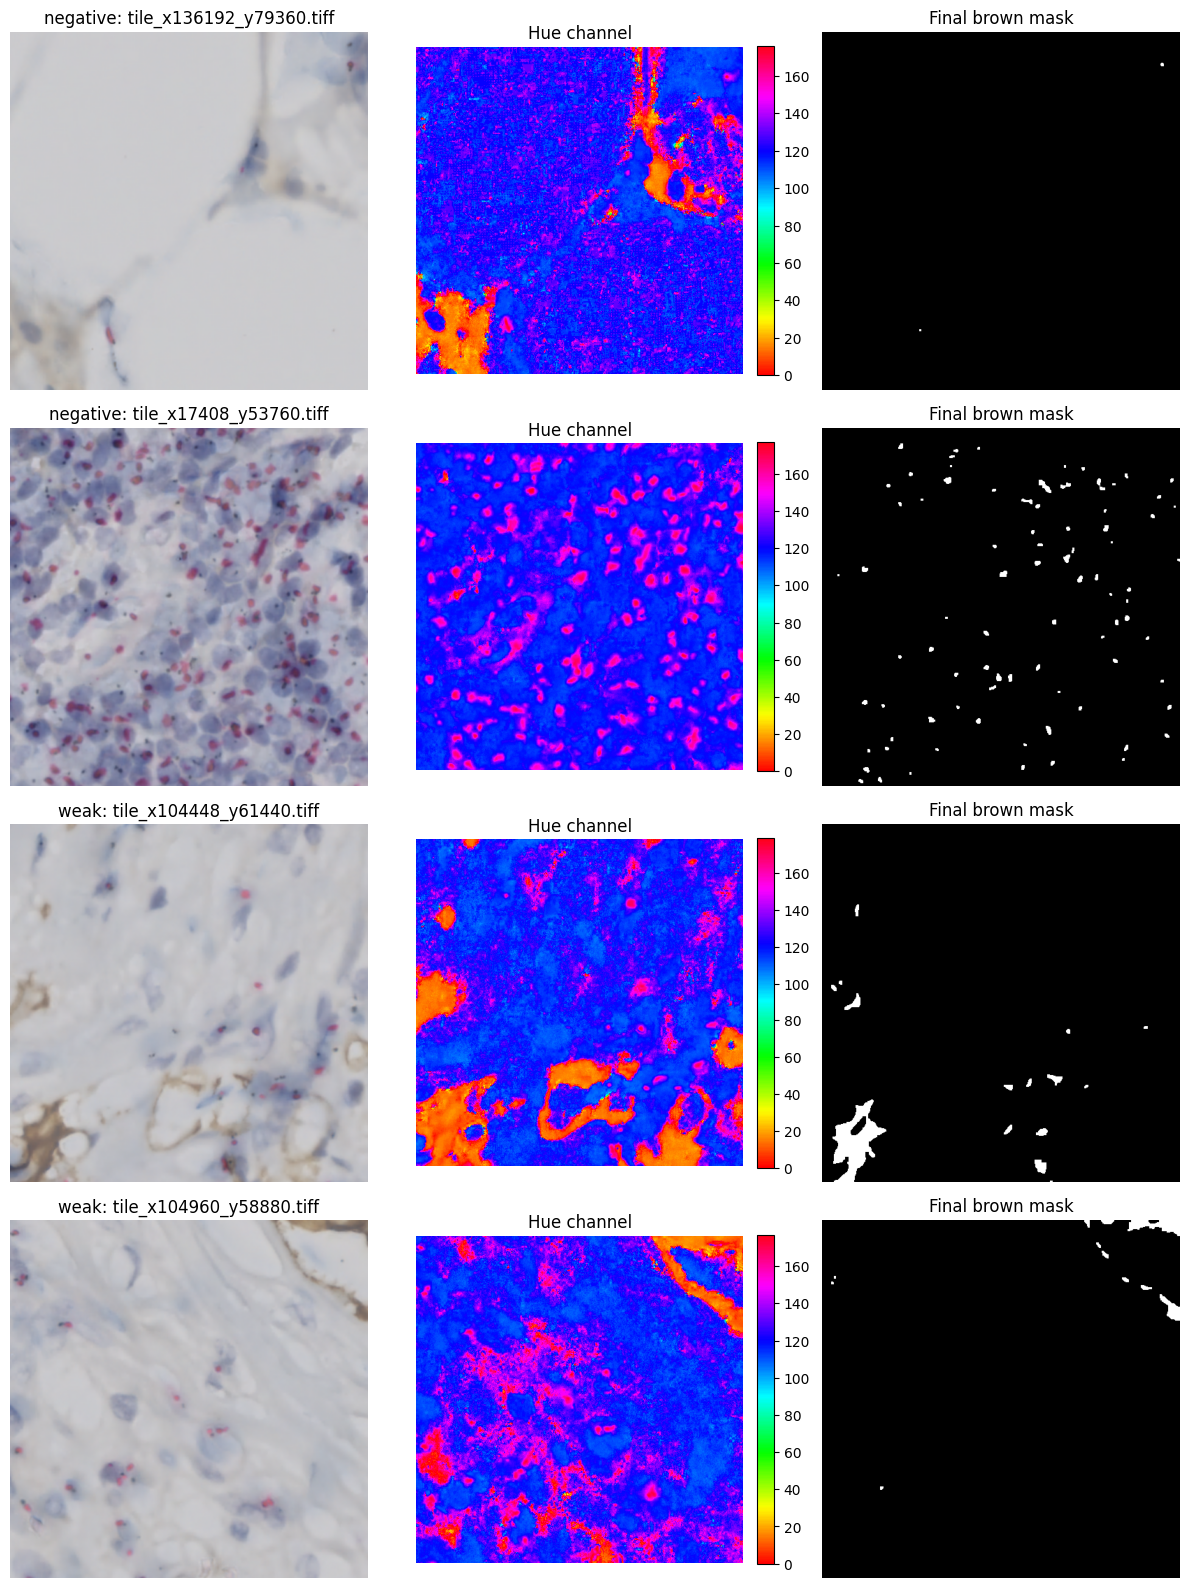

In [6]:
# Validate HSV-based pseudo-mask on negative and weak samples with Hue visualization
def preview_hsv_masks(paths_by_cat: dict, categories=('negative', 'weak'), samples_per_cat: int = 2):
    selected_items = []
    for cat in categories:
        if cat not in paths_by_cat:
            continue
        paths = paths_by_cat.get(cat, [])
        chosen = random.sample(paths, k=min(samples_per_cat, len(paths))) if paths else []
        for p in chosen:
            selected_items.append((cat, p))
    rows = len(selected_items)
    if rows == 0:
        print('No samples found for categories:', categories)
        return
    fig, axes = plt.subplots(rows, 3, figsize=(12, 4 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, 0)
    for i, (cat, p) in enumerate(selected_items):
        img = _read_rgb_uint8(p)
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        hue = hsv[..., 0]
        mask = generate_pseudo_mask(p)
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{cat}: {p.name}")
        axes[i, 0].axis('off')
        im1 = axes[i, 1].imshow(hue, cmap='hsv')
        axes[i, 1].set_title('Hue channel')
        axes[i, 1].axis('off')
        fig.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)
        axes[i, 2].imshow(mask, cmap='gray')
        axes[i, 2].set_title('Final brown mask')
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()

preview_hsv_masks(rep_paths_by_cat, categories=('negative', 'weak'), samples_per_cat=2)

### Step 2 – 具有磁碟遮罩快取與 2k 影像隨機裁切的資料集

In [6]:
# Dataset for large images (e.g., 2048x2048) with cached full-size masks and on-the-fly 512x512 crops
class LargeImagePseudoMaskDataset(Dataset):
    def __init__(self, image_root: Path, mask_root: Path, transform=None, cache_ext: str = '.png', crop_size: int = 512, center_crop_val: bool = False):
        self.image_root = image_root
        self.mask_root = mask_root
        self.transform = transform
        self.cache_ext = cache_ext
        self.crop_size = crop_size
        self.center_crop_val = center_crop_val
        self.samples = sorted([p for p in image_root.rglob('*') if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.tif', '.tiff')])
        if not self.samples:
            raise RuntimeError(f'No images found under {image_root}')
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx: int):
        img_path = self.samples[idx]
        rel = img_path.relative_to(self.image_root)
        mask_path = (self.mask_root / rel).with_suffix(self.cache_ext)
        mask_path.parent.mkdir(parents=True, exist_ok=True)
        img = np.array(Image.open(img_path).convert('RGB'))
        if mask_path.exists():
            mask = np.array(Image.open(mask_path))
        else:
            mask = generate_pseudo_mask(img_path)
            Image.fromarray(mask).save(mask_path)
        # Apply crop + augmentations
        if self.transform is not None:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            elif mask.ndim == 3 and mask.shape[0] != 1:
                mask = mask.permute(2, 0, 1)
            mask = mask.float() / 255.0
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0).float() / 255.0
        return img, mask

# Training transform: random crop to 512 then augment
# 加入 PadIfNeeded 處理小於 512x512 的圖片
train_transform = A.Compose([
    A.PadIfNeeded(min_height=CROP_SIZE, min_width=CROP_SIZE, 
                  border_mode=cv2.BORDER_REFLECT_101),
    A.RandomCrop(height=CROP_SIZE, width=CROP_SIZE),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    A.ElasticTransform(alpha=50, sigma=5, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Validation transform: deterministic center crop then normalize
# 加入 PadIfNeeded 處理小於 512x512 的圖片
val_transform = A.Compose([
    A.PadIfNeeded(min_height=CROP_SIZE, min_width=CROP_SIZE,
                  border_mode=cv2.BORDER_REFLECT_101),
    A.CenterCrop(height=CROP_SIZE, width=CROP_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
# 


### Step 3 – U-Net 模型（segmentation_models_pytorch）和損失函數

In [7]:
# Model, losses, and metrics
model = smp.Unet(
    encoder_name='efficientnet-b0',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None
).to(device)

dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
focal_loss = smp.losses.FocalLoss(mode='binary')

def loss_fn(pred, target):
    return dice_loss(pred, target) + focal_loss(pred, target)

def iou_score(pred, target, threshold: float = 0.5, eps: float = 1e-6):
    probs = torch.sigmoid(pred)
    pred_bin = (probs > threshold).float()
    target_bin = (target > threshold).float()
    intersection = (pred_bin * target_bin).sum(dim=(1, 2, 3))
    union = pred_bin.sum(dim=(1, 2, 3)) + target_bin.sum(dim=(1, 2, 3)) - intersection
    return ((intersection + eps) / (union + eps)).mean().item()

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)


# 

### Step 4 & 5 – 在代表性資料集上進行驗證的訓練循環

In [8]:
from torch.cuda.amp import autocast, GradScaler
# ========== 1. 預載入資料集類別 ==========
class PreloadedDataset(torch.utils.data.Dataset):
    """將整個 dataset 預載入到 RAM，消除 I/O 瓶頸"""
    def __init__(self, base_dataset, desc="Loading"):
        print(f"[{desc}] 預載入 {len(base_dataset)} 個樣本到 RAM...")
        t0 = perf_counter()
        self.data = []
        for i in range(len(base_dataset)):
            self.data.append(base_dataset[i])
            if (i + 1) % 2000 == 0:
                print(f"  已載入 {i+1}/{len(base_dataset)}...")
        print(f"[{desc}] 完成！耗時 {perf_counter()-t0:.1f}s")
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    def __len__(self):
        return len(self.data)

# ========== 2. 創建 AMP GradScaler ==========
scaler = GradScaler(enabled=(device.type == 'cuda'))

/tmp/ipykernel_158262/293816244.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == 'cuda'))


In [9]:
# ========== 3. 優化的訓練函數（使用 AMP 混合精度）==========
def train_one_epoch(loader, model, optimizer, device):
    model.train()
    print('Training on device:', device)
    running_loss = 0.0
    running_iou = 0.0
    batch_times = []
    
    for imgs, masks in loader:
        t0 = perf_counter()
        
        # 使用 non_blocking 加速數據傳輸
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        # 使用 set_to_none=True 比 zero_grad() 更快
        optimizer.zero_grad(set_to_none=True)
        
        # AMP: 自動混合精度訓練
        with autocast():
            preds = model(imgs)
            loss = loss_fn(preds, masks)
        
        # 縮放梯度並反向傳播
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * imgs.size(0)
        with torch.no_grad():
            running_iou += iou_score(preds.detach(), masks)
        
        batch_times.append(perf_counter() - t0)
    
    avg_bt = float(np.mean(batch_times)) if batch_times else 0.0
    return running_loss / len(loader.dataset), running_iou / len(loader), avg_bt

In [10]:
# ========== 4. 優化的評估函數 ==========
@torch.no_grad()
def evaluate(loader, model, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    
    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        with autocast():
            preds = model(imgs)
            loss = loss_fn(preds, masks)
        
        running_loss += loss.item() * imgs.size(0)
        running_iou += iou_score(preds, masks)
    
    return running_loss / len(loader.dataset), running_iou / len(loader)

In [11]:
# ========== 5. 資料集設置 ==========
full_ds_train = LargeImagePseudoMaskDataset(
    FULL_DATA_DIR,
    MASK_CACHE_DIR,
    transform=train_transform
)
full_ds_val = LargeImagePseudoMaskDataset(
    FULL_DATA_DIR,
    MASK_CACHE_DIR,
    transform=val_transform
)

num_samples = len(full_ds_train)
train_size = int(0.9 * num_samples)
val_size = num_samples - train_size
indices = torch.randperm(
    num_samples,
    generator=torch.Generator().manual_seed(0)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_ds = torch.utils.data.Subset(full_ds_train, train_indices)
val_ds = torch.utils.data.Subset(full_ds_val, val_indices)

In [12]:
# ========== 6. 預載入資料到 RAM（核心優化！）==========
print("=" * 60)
print("開始預載入資料到 RAM... (請等待 1-3 分鐘)")
print("這將大幅提升 GPU 使用率！")
print("=" * 60)

train_ds_preloaded = PreloadedDataset(train_ds, desc="Train")
val_ds_preloaded = PreloadedDataset(val_ds, desc="Val")

# Representative set
rep_mask_dir = MASK_CACHE_DIR / 'rep_eval'
rep_mask_dir.mkdir(parents=True, exist_ok=True)
rep_ds = LargeImagePseudoMaskDataset(
    REP_DIR,
    rep_mask_dir,
    transform=val_transform
)
rep_ds_preloaded = PreloadedDataset(rep_ds, desc="Rep")
BATCH_SIZE = 32  # 3070 Ti 8GB VRAM 推薦值
train_loader = DataLoader(
    train_ds_preloaded,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # 資料在 RAM，不需要 workers
    pin_memory=True
)
val_loader = DataLoader(
    val_ds_preloaded,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
rep_loader = DataLoader(
    rep_ds_preloaded,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

開始預載入資料到 RAM... (請等待 1-3 分鐘)
這將大幅提升 GPU 使用率！
[Train] 預載入 9000 個樣本到 RAM...
  已載入 2000/9000...
  已載入 4000/9000...
  已載入 6000/9000...
  已載入 8000/9000...
[Train] 完成！耗時 89.7s
[Val] 預載入 1000 個樣本到 RAM...
[Val] 完成！耗時 4.8s
[Rep] 預載入 33 個樣本到 RAM...
[Rep] 完成！耗時 0.2s


In [13]:
print(f"\n優化設置:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Num workers: 0 (資料已在 RAM)")
print(f"  使用 AMP 混合精度: True")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Rep batches: {len(rep_loader)}")


優化設置:
  Batch size: 32
  Num workers: 0 (資料已在 RAM)
  使用 AMP 混合精度: True
  Train batches: 282
  Val batches: 32
  Rep batches: 2


In [14]:
# ========== 8. 開始訓練 ==========
num_epochs = 50
print('\n' + "=" * 60)
print('開始訓練...')
print("=" * 60)

for epoch in range(num_epochs):
    epoch_start = perf_counter()
    train_loss, train_iou, train_bt = train_one_epoch(
        train_loader,
        model,
        optimizer,
        device
    )
    val_loss, val_iou = evaluate(val_loader, model, device)
    rep_loss, rep_iou = evaluate(rep_loader, model, device)
    lr_scheduler.step(val_iou)
    epoch_time = perf_counter() - epoch_start
    print(
        f"Epoch {epoch+1:2d}/{num_epochs}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"val_iou={val_iou:.3f} rep_iou={rep_iou:.3f} "
        f"train_bt={train_bt*1000:.1f}ms/batch epoch={epoch_time:.1f}s"
    )
# 


開始訓練...
Training on device: cuda


/tmp/ipykernel_158262/4106629730.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


/tmp/ipykernel_158262/829412175.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch  1/50: train_loss=0.1945 val_loss=0.1259 val_iou=0.667 rep_iou=0.714 train_bt=179.6ms/batch epoch=63.1s
Training on device: cuda
Epoch  2/50: train_loss=0.1121 val_loss=0.0893 val_iou=0.768 rep_iou=0.842 train_bt=146.9ms/batch epoch=54.5s
Training on device: cuda
Epoch  3/50: train_loss=0.0901 val_loss=0.0553 val_iou=0.796 rep_iou=0.835 train_bt=146.9ms/batch epoch=53.0s
Training on device: cuda
Epoch  4/50: train_loss=0.0786 val_loss=0.0634 val_iou=0.784 rep_iou=0.843 train_bt=146.9ms/batch epoch=52.9s
Training on device: cuda
Epoch  5/50: train_loss=0.0749 val_loss=0.0697 val_iou=0.795 rep_iou=0.858 train_bt=146.9ms/batch epoch=51.7s
Training on device: cuda
Epoch  6/50: train_loss=0.0660 val_loss=0.0865 val_iou=0.768 rep_iou=0.837 train_bt=146.9ms/batch epoch=52.5s
Training on device: cuda
Epoch  7/50: train_loss=0.0573 val_loss=0.0447 val_iou=0.818 rep_iou=0.868 train_bt=146.9ms/batch epoch=52.6s
Training on device: cuda
Epoch  8/50: train_loss=0.0563 val_loss=0.0454 val_iou=

### Step 6 – 2k 影像的滑動視窗推論與可視化

In [15]:
MODEL_DIR = Path("process/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
# Save trained model checkpoint
ckpt = {
    "epoch": num_epochs,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scaler_state": scaler.state_dict() if scaler is not None else None,
    "val_iou": val_iou,
    "rep_iou": rep_iou,
}
print(ckpt)
ckpt_path = MODEL_DIR / f"unet3.pt"
torch.save(ckpt, ckpt_path)
print(f"Checkpoint saved to: {ckpt_path.resolve()}")

{'epoch': 50, 'model_state': OrderedDict([('encoder._conv_stem.weight', tensor([[[[ 2.5563e-02,  5.2419e-03,  9.4508e-03],
          [-1.6760e-01, -1.2577e-01, -1.7437e-02],
          [-3.5232e-01, -4.9005e-01, -6.3624e-02]],

         [[ 1.6428e-01,  1.6445e-01,  1.4282e-01],
          [ 4.3663e-02,  4.9158e-02,  1.6413e-01],
          [-3.3671e-01, -5.0869e-01,  8.9589e-02]],

         [[ 5.6731e-02,  4.5958e-02,  4.8983e-02],
          [-6.0371e-02, -5.4499e-02,  5.0396e-02],
          [-1.8410e-01, -2.2736e-01, -3.9009e-02]]],


        [[[ 9.1216e-01, -1.1516e+00,  1.3073e-02],
          [ 7.2403e-01, -1.0191e-01,  1.1709e-01],
          [ 2.6960e-01, -2.2977e-01,  4.5463e-02]],

         [[ 1.5779e+00, -2.4278e+00, -1.5245e-01],
          [ 1.3034e+00, -5.7937e-01,  1.5725e-01],
          [ 4.0956e-01, -4.3729e-01,  1.2238e-01]],

         [[ 4.5679e-01, -8.1553e-01, -1.7460e-01],
          [ 3.9875e-01, -2.7291e-01, -6.0009e-02],
          [ 6.1195e-02, -2.6070e-01, -9.6351e-02]

/tmp/ipykernel_158262/843521241.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():


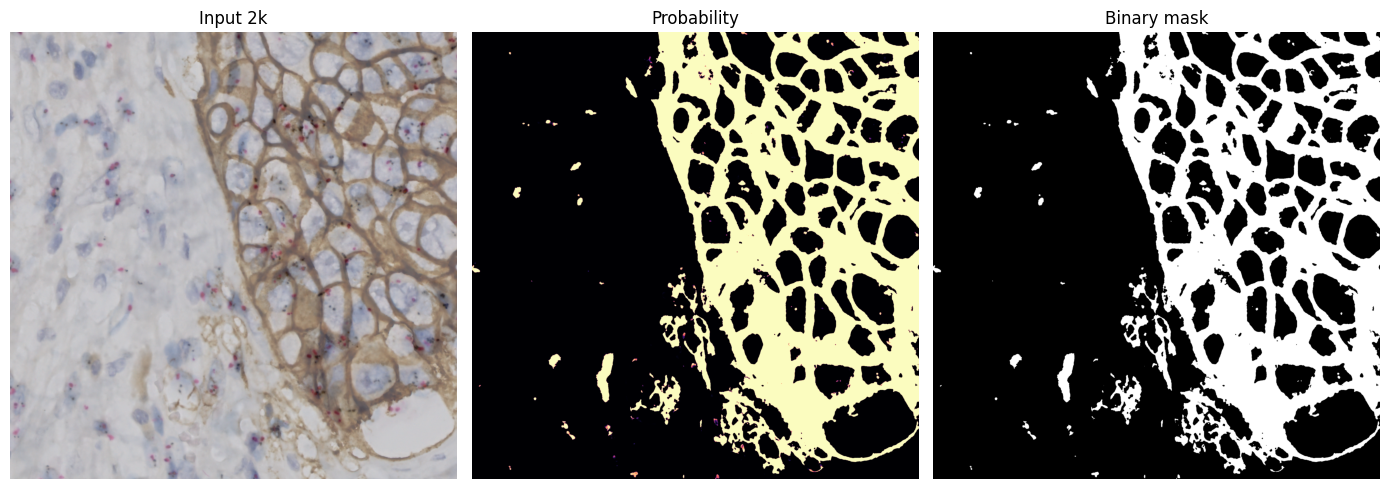

In [17]:
# 2k inference (robust if kernel was restarted)
# Ensure device & model dir
if "device" not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt_path = MODEL_DIR / "unet3.pt"
assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}"

# Recreate model if missing
if "model" not in globals():
    model = smp.Unet(
        encoder_name='efficientnet-b0',
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None,
    ).to(device)

# Load checkpoint
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state["model_state"])
model.eval()

# Simple full-image preprocessing (no crop) for 2k TIFF
inference_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

def preprocess_image(path: Path):
    img = np.array(Image.open(path).convert("RGB"))
    augmented = inference_transform(image=img)
    tensor = augmented["image"]  # CHW float
    return img, tensor

def run_inference(image_path: Path, model: torch.nn.Module, device: torch.device, threshold: float = 0.5):
    img_np, img_t = preprocess_image(image_path)
    with torch.no_grad(), autocast():
        logits = model(img_t.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    mask_bin = (prob > threshold).astype(np.uint8) * 255
    return img_np, prob, mask_bin

# Paths
TEST_IMAGE = Path("process/tile/tile_x153600_y59392.tiff")
OUTPUT_DIR = Path("process/test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Run inference
raw_img, prob_map, mask_bin = run_inference(TEST_IMAGE, model, device, threshold=0.5)

# Save outputs
Image.fromarray(mask_bin).save(OUTPUT_DIR / "mask_binary.png")
np.save(OUTPUT_DIR / "prob.npy", prob_map)
plt.imsave(OUTPUT_DIR / "prob_vis.png", prob_map, cmap="magma")

# Quick visualization
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1); plt.imshow(raw_img); plt.title("Input 2k"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(prob_map, cmap="magma"); plt.title("Probability"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(mask_bin, cmap="gray"); plt.title("Binary mask"); plt.axis("off")
plt.tight_layout()
plt.show()

正在執行拓撲運算 (這可能需要幾秒鐘)...


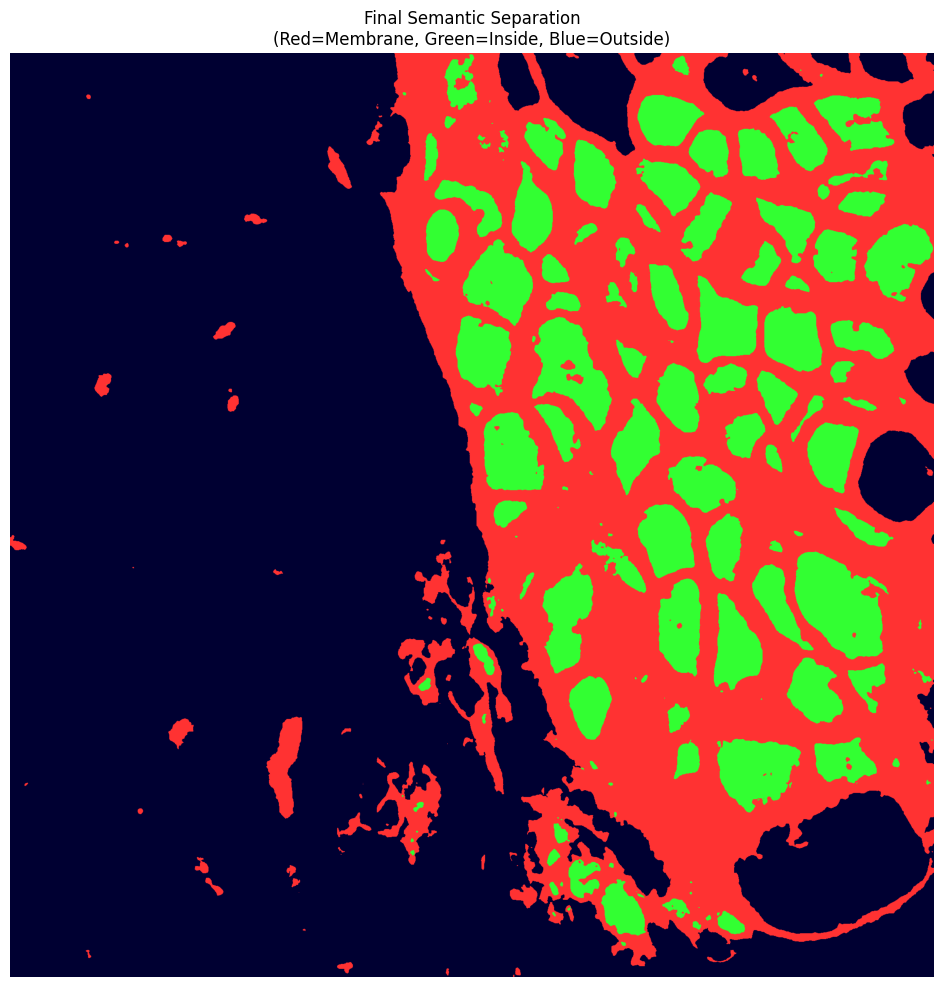

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def visualize_final_separation_2k(mask_bin_path):
    # 1. 讀取你剛剛生成的 Binary Mask
    # 確保是 0 或 1 的二值化圖片
    mask_ring = np.array(Image.open(mask_bin_path))
    mask_ring = (mask_ring > 128).astype(np.uint8) # 確保是 0/1

    print("正在執行拓撲運算 (這可能需要幾秒鐘)...")
    
    # 2. 關鍵步驟：孔洞填充 (Binary Fill Holes)
    # 這步會把所有 "蜂巢內的洞" 填起來，變成實心
    mask_filled = ndimage.binary_fill_holes(mask_ring).astype(np.uint8)
    
    # 3. 集合運算分離三區
    # A. 內部區域 (Inside) = 實心圓 - 環
    mask_inside = cv2.subtract(mask_filled, mask_ring)
    
    # B. 外部區域 (Outside) = 全白 - 實心圓
    mask_outside = 1 - mask_filled

    # 4. 視覺化合成 (用彩色顯示比較清楚)
    # 建立一個 RGB 畫布
    h, w = mask_ring.shape
    vis_img = np.zeros((h, w, 3), dtype=np.uint8)
    
    # 定義顏色
    # 紅色表示牆壁 (Membrane)
    vis_img[mask_ring == 1] = [255, 50, 50]   
    # 綠色表示內部 (Nuclei/Cytoplasm)
    vis_img[mask_inside == 1] = [50, 255, 50] 
    # 藍色表示外部 (Background/Stroma)
    vis_img[mask_outside == 1] = [0, 0, 50]   

    # 5. 畫圖
    plt.figure(figsize=(12, 12))
    plt.title("Final Semantic Separation\n(Red=Membrane, Green=Inside, Blue=Outside)")
    plt.imshow(vis_img)
    plt.axis('off')
    plt.show()

    return mask_inside, mask_outside

# === 執行 ===
# 指向你剛剛存的 mask_binary.png
MASK_PATH = OUTPUT_DIR / "mask_binary.png"
mask_in, mask_out = visualize_final_separation_2k(MASK_PATH)

In [19]:
# ================= 1. 參數設定區 (可微調) =================
# 路徑設定
MODEL_PATH = "process/models/unet3.pt"     # 你的模型路徑
IMAGE_PATH = "process/tile/tile_x153600_y59392.tiff" # 你要測試的圖片路徑
OUTPUT_DIR = Path("process/test")# 只輸出最終成品的資料夾
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# 閾值設定
MASK_THRESHOLD = 0.5        # U-Net 機率閾值
MIN_WALL_SIZE = 300         # 清洗牆壁用：小於這個面積的白色區塊會被擦掉 (視為誤判的紅點)
DOT_MIN_AREA = 5            # 點偵測用：太小的點當雜訊
DOT_MAX_AREA = 250          # 點偵測用：太大的點當細胞核或邊緣，忽略

In [20]:
# ================= 2. 模型載入與初始化 =================
def load_model(path, device):
    print(f"🚀 正在載入模型: {path}...")
    model = smp.Unet(
        encoder_name='efficientnet-b0',
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None,
    ).to(device)
    
    # 載入權重
    checkpoint = torch.load(path, map_location=device)
    # 檢查是否包含 "model_state" key，若沒有則直接載入
    if "model_state" in checkpoint:
        model.load_state_dict(checkpoint["model_state"])
    else:
        model.load_state_dict(checkpoint)
        
    model.eval()
    return model

In [21]:
# ================= 3. 核心功能函式庫 =================

def preprocess_image(image_path):
    """讀取並預處理圖片"""
    img_pil = Image.open(image_path).convert("RGB")
    img_np = np.array(img_pil)
    
    transform = A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
    
    augmented = transform(image=img_np)
    return img_np, augmented["image"]

def clean_unet_mask(pred_mask, min_size):
    """
    [關鍵步驟] 清洗 U-Net 輸出
    把誤判為牆壁的紅點(小白點)擦掉，變回黑色背景，這樣稍後才能被算進內部區域。
    """
    mask_bool = pred_mask > 0
    # 移除小物件 (Connectivity=2 代表 8-連通)
    cleaned_bool = morphology.remove_small_objects(mask_bool, min_size=min_size, connectivity=2)
    return cleaned_bool.astype(np.uint8)

🚀 正在載入模型: process/models/unet3.pt...
🧠 正在進行 U-Net 分割...
🧹 正在清洗遮罩 (移除小於 300 像素的雜訊)...
🧩 正在進行拓撲運算 (分離內外)...
🎨 正在繪製結果...


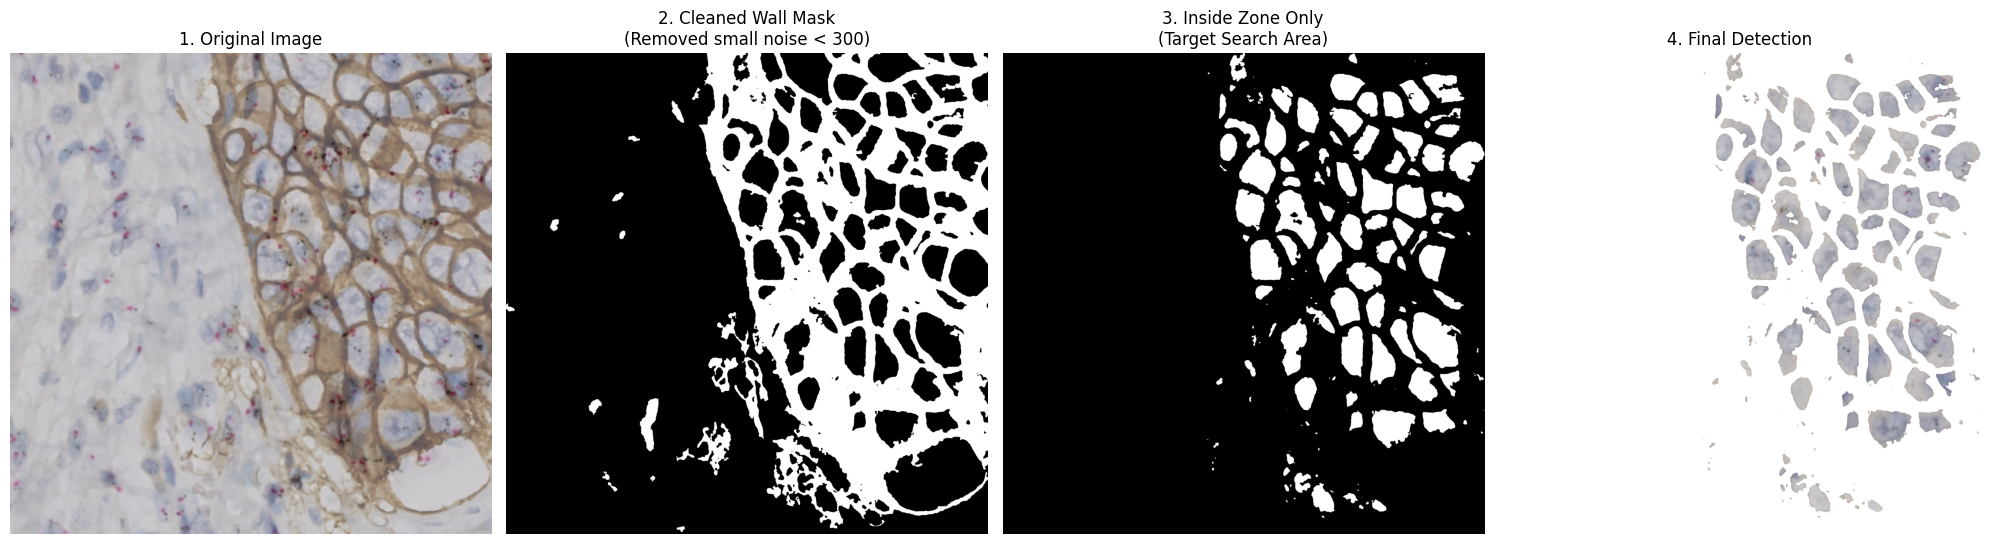

✅ 最終影像已儲存: process/test/final_detection.png


In [22]:
def detect_dots_in_inside_zone(raw_img, inside_mask):
    """
    在 '內部區域' 尋找原圖的紅黑點
    """
    # 轉 HSV
    hsv = cv2.cvtColor(raw_img, cv2.COLOR_RGB2HSV)
    
    # --- 定義紅點 (Red) ---
    # 範圍1 (跨越 0 度)
    lower_red1 = np.array([0, 40, 0])
    upper_red1 = np.array([15, 255, 255])
    # 範圍2 (跨越 180 度)
    lower_red2 = np.array([160, 40, 0])
    upper_red2 = np.array([180, 255, 255])
    mask_red = cv2.bitwise_or(cv2.inRange(hsv, lower_red1, upper_red1), 
                              cv2.inRange(hsv, lower_red2, upper_red2))
    
    # --- 定義黑點 (Black/Dark Blue) ---
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([180, 255, 60]) # Value < 60 代表很黑
    mask_black = cv2.inRange(hsv, lower_black, upper_black)

    # 合併潛在候選點
    mask_candidates = cv2.bitwise_or(mask_red, mask_black)

    # [重點] 只保留 Inside Mask 裡面的點
    mask_valid = cv2.bitwise_and(mask_candidates, mask_candidates, mask=inside_mask)

    # --- 形態學與面積篩選 ---
    # 去除噪點 (開運算)
    kernel = np.ones((2,2), np.uint8)
    mask_clean = cv2.morphologyEx(mask_valid, cv2.MORPH_OPEN, kernel)
    
    # 輪廓篩選
    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    final_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # 濾掉太大(可能是細胞邊緣)或太小(雜訊)的東西
        if DOT_MIN_AREA < area < DOT_MAX_AREA:
            final_contours.append(cnt)
            
    return final_contours

# ================= 4. 主流程 (Pipeline) =================

def run_full_analysis():
    # A. 準備模型與圖片
    model = load_model(MODEL_PATH, DEVICE)
    original_img, img_tensor = preprocess_image(IMAGE_PATH)
    
    # B. U-Net 推論
    print("🧠 正在進行 U-Net 分割...")
    with torch.no_grad():
        # 加上 autocast 確保與訓練時一致 (若是 CUDA)
        with torch.amp.autocast('cuda') if DEVICE=='cuda' else torch.no_grad():
            logits = model(img_tensor.unsqueeze(0).to(DEVICE))
            prob = torch.sigmoid(logits).squeeze().cpu().numpy()
            
    # 初步二值化 (包含雜訊)
    mask_raw = (prob > MASK_THRESHOLD).astype(np.uint8)

    # C. [清洗] 擦掉誤判的紅點
    print(f"🧹 正在清洗遮罩 (移除小於 {MIN_WALL_SIZE} 像素的雜訊)...")
    mask_wall_clean = clean_unet_mask(mask_raw, min_size=MIN_WALL_SIZE)

    # D. [拓撲] 計算內部區域
    print("🧩 正在進行拓撲運算 (分離內外)...")
    # 填滿所有封閉區域 -> 得到 (牆壁 + 內部)
    mask_filled = ndimage.binary_fill_holes(mask_wall_clean).astype(np.uint8)
    
    # 內部區域 = 填滿的 - 只有牆壁的
    mask_inside = cv2.subtract(mask_filled, mask_wall_clean)
    # ================= 5. 結果視覺化 =================
    print("🎨 正在繪製結果...")
    
    fig, ax = plt.subplots(1, 4, figsize=(20, 6))
    
    # 圖 1: 原圖
    ax[0].imshow(original_img)
    ax[0].set_title("1. Original Image")
    ax[0].axis('off')
    
    # 圖 2: 清洗後的牆壁 (注意紅點應該要不見，變黑色)
    ax[1].imshow(mask_wall_clean, cmap='gray')
    ax[1].set_title(f"2. Cleaned Wall Mask\n(Removed small noise < {MIN_WALL_SIZE})")
    ax[1].axis('off')
    
    # 圖 3: 內部區域 (這是我們的搜尋範圍)
    ax[2].imshow(mask_inside, cmap='gray')
    ax[2].set_title("3. Inside Zone Only\n(Target Search Area)")
    ax[2].axis('off')
    
    # 圖 4: 最終結果 (原圖 + 綠色圈圈)
    # 製作一張畫好圈圈的圖
    final_vis = original_img.copy()
    # 把背景塗白 (讓綠色圈圈更明顯)
    mask_outside = 1 - mask_inside
    final_vis[mask_outside == 1] = [255, 255, 255] # 背景變白
    ax[3].imshow(final_vis)
    ax[3].set_title(f"4. Final Detection")
    ax[3].axis('off')
    
    plt.tight_layout()
    plt.show()

    # 只輸出最終成品
    final_path = OUTPUT_DIR / "final_detection.png"
    Image.fromarray(final_vis).save(final_path, quality=95)
    print(f"✅ 最終影像已儲存: {final_path}")

# 執行程式
if __name__ == "__main__":
    run_full_analysis()


# 測試+屍體區

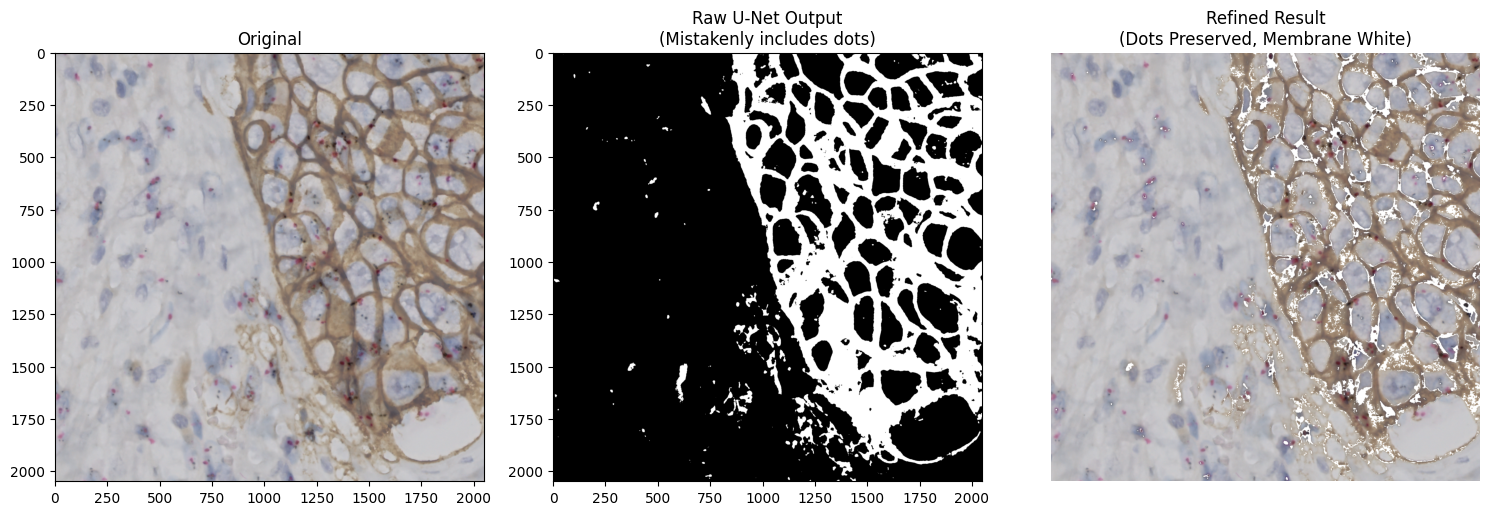

In [8]:
def refine_unet_output(original_img, unet_mask_prediction):
    """
    original_img: 原始 RGB 影像
    unet_mask_prediction: U-Net 輸出的細胞膜 Mask (0 or 255/1)
    """
    # 轉 HSV 空間以鎖定紅/黑點
    hsv = cv2.cvtColor(original_img, cv2.COLOR_RGB2HSV)
    
    # 1. 建立「絕對紅點」遮罩 (Red Dot Mask)
    # 紅色在 HSV 跨越 0 度，需取兩段
    lower_red1 = np.array([0, 40, 40])
    upper_red1 = np.array([15, 255, 255])
    lower_red2 = np.array([160, 40, 40])
    upper_red2 = np.array([180, 255, 255])
    
    mask_red = cv2.bitwise_or(
        cv2.inRange(hsv, lower_red1, upper_red1), 
        cv2.inRange(hsv, lower_red2, upper_red2)
    )
    
    # 2. 建立「絕對黑點」遮罩 (Black Dot Mask)
    # 黑色：亮度 (Value) 極低，飽和度 (Saturation) 不限
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([180, 80, 80]) 
    mask_black = cv2.inRange(hsv, lower_black, upper_black)
    
    # 合併保護區：這些區域絕對不是膜
    mask_dots_protection = cv2.bitwise_or(mask_red, mask_black)
    
    # 膨脹保護區一點點，確保邊緣不會被吃到 (Optional)
    kernel = np.ones((3,3), np.uint8)
    mask_dots_protection = cv2.dilate(mask_dots_protection, kernel, iterations=1)
    
    # 3. 修正 U-Net 的預測
    # 邏輯：雖然 U-Net 說是膜，但如果是紅/黑點，就「否決」它
    # final_mask = unet_mask AND (NOT dot_mask)
    final_membrane_mask = cv2.subtract(unet_mask_prediction, mask_dots_protection)
    
    # 4. 產生結果圖
    result_img = original_img.copy()
    # 只有在「修正後的 Mask」區域才塗白
    # 這樣原本是紅點的地方，因為被從 Mask 中移除了，所以會保留原圖的紅點顏色
    result_img[final_membrane_mask > 0] = [255, 255, 255]
    
    return result_img, final_membrane_mask

# --- 模擬使用範例 ---
# 假設您已經跑完 U-Net 得到 pred_mask
# image = ...
# pred_mask = model.predict(image) ...

# 這裡我用前面生成的 mask 模擬您的 U-Net 輸出
# (在您的程式中，請直接傳入 model 的輸出 mask)
import cv2
img = cv2.imread('process/tile/tile_x153600_y59392.tiff')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 模擬一個不完美的 U-Net Mask (這裡假設它連紅點都圈進去了)
# 為了演示，我們重新生成一個包含所有棕色與紅色的 Mask
from skimage.color import rgb2hed
from skimage.exposure import rescale_intensity
ihc_hed = rgb2hed(img_rgb)
dab = rescale_intensity(ihc_hed[:, :, 2], out_range=(0, 255)).astype(np.uint8)
_, simulated_unet_mask = cv2.threshold(dab, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
# 這個 simulated_unet_mask 現在包含了膜，但也包含了部分紅點（錯誤）

# 執行修正
result_img, refined_mask = refine_unet_output(img_rgb, simulated_unet_mask)

# 顯示比較
fig, ax = plt.subplots(1, 3, figsize=(15, 6))
ax[0].imshow(img_rgb)
ax[0].set_title("Original")
ax[1].imshow(simulated_unet_mask, cmap='gray')
ax[1].set_title("Raw U-Net Output\n(Mistakenly includes dots)")
ax[2].imshow(result_img)
ax[2].set_title("Refined Result\n(Dots Preserved, Membrane White)")
plt.axis('off')
plt.tight_layout()
plt.savefig('unet_refinement_demo.png')
plt.show()